# Yeti-Travel Group Project

## Context

Yeti Travel is a travel agency specialised in school trips. Over the past year the
company has registered a worrying drop in sales, and the drop is especially visible
among repeat customers. Since most of the revenue comes from loyal clients, this is
a real threat to the continuity of the business.

Our goal is twofold:

1. Build a predictive model that estimates the probability that a client (a school)
   will come back the following year (`Retained = 1`) or leave (`Retained = 0`).
2. Identify the features that best describe loyal customers, so that the agency can
   design targeted retention strategies (personalised offers, tighter relationships
   with at-risk schools, and so on).

## Data

The data is split across three departments, each with its own snapshot at the end
of "year 1":

- **Sales**: trip-level commercial info (program, grades, travel mode, dates,
  passengers). It contains the target `Retained`.
- **Finance**: financial info (tuition, insurance take-up, revenue, payment
  modality).
- **CRM**: school-level info (school type, size, region, parent meetings, income
  level).

## 1. Setup and imports

Standard data-science stack: `pandas` and `numpy` for data handling,
`matplotlib` and `seaborn` for plots, and `scikit-learn` for the ML pipeline
(preprocessing, cross-validation, models).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Loading the data

We load both the training (`_model`) and the test (`_test`) versions of the three
datasets. The training set is labelled (`Retained` is known) and is what we use to
fit the model. The test set is unlabelled, and the predictions on it are what we
actually submit.

We keep every dataframe inside a single dictionary so we can loop over them and
produce a quick shape + missing-values check without repeating code.

In [2]:
# path to the data folder
path = 'data/'
files = ['sales', 'finance', 'crm']

# initialize dictionary of datasets
data = {}
for name in files:
    data[f'{name}_train'] = pd.read_csv(f'{path}{name}_model.csv')
    data[f'{name}_test'] = pd.read_csv(f'{path}{name}_test.csv')

# quick summary for each of the 6 dataframes
for key, df in data.items():
    # separator made by = sign
    print(f"\n{'='*40}")
    # print the specific df and the corresponding shape
    print(f"{key}: {df.shape}")
    # print first 3 rows
    print(df.head(3).to_string())
    # summary of missing values (only those with more than 0 missing)
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")


sales_train: (4153, 24)
  ID_SALES Program_Code  From_Grade  To_Grade Group_State  Days Travel_Type Departure_Date Return_Date   Early_RPL  Latest_RPL  Cancelled_Pax  Total_Discount_Pax Initial_System_Date SPR_Product_Type  FPP  Total_Pax DepartureMonth GroupGradeTypeLow GroupGradeTypeHigh GroupGradeType MajorProgramCode FPP_to_School_enrollment  Retained
0  CC1387A           CC        10.0      10.0          CA    24           A     04/07/2019  05/01/2019  05/11/2018  04/10/2018              2                   1          04/01/2018       East Coast   26         29        January                 K               High        K->High                C        0,126429354314411         1
1   CC139A           CC         5.0       6.0          CA    18           A     04/30/2019  05/18/2019  03/05/2018  03/06/2018              2                   3          03/16/2018       East Coast   21         22        January                PK             Middle     PK->Middle                C        0

## 3. Column configuration and merging

### 3.1 Column families

Before touching the data, we declare the column families once at the top. If a new
column needs a specific treatment later, we add it here and the rest of the
pipeline picks it up automatically, without having to hunt for hard-coded lists
everywhere.

In [3]:
decimal_comma_cols = [
    'FPP_to_School_enrollment', 'FRP_Take_up_percent_',
    'EZ_Pay_Take_Up_Rate', 'FPP_to_PAX',
]

date_cols = [
    'Departure_Date', 'Return_Date',
    'Early_RPL', 'Latest_RPL',
    'Deposit_Date', 'Initial_System_Date',
    'FirstMeeting', 'LastMeeting',
]

binary_cols = ['School_Sponsor', 'Parent_Meeting_Flag', 'SPR_New_Existing']

categorical_cols = [
    'Program_Code', 'Travel_Type', 'Group_State',
    'SPR_Product_Type', 'MajorProgramCode',
    'GroupGradeTypeLow', 'GroupGradeTypeHigh', 'GroupGradeType',
    'DepartureMonth', 'Special_Pay',
    'Poverty_Code', 'Region', 'School_Type', 'Income_Level',
    'SchoolGradeTypeLow', 'SchoolGradeTypeHigh', 'SchoolGradeType',
    'SchoolSizeIndicator', 'CRM_Segment',
]

### 3.2 Merging the three datasets

The three datasets share the same underlying trip, but each department uses its
own ID format:

| Dataset  | Example ID  |
|----------|-------------|
| Sales    | `CC1040A`   |
| Finance  | `CP1040`    |
| CRM      | `01040K`    |

The common element is the numeric part (`1040`). We extract it with a regex and
use it as the join key.

One thing we learned the hard way: if you extract the digits as strings, the CRM
IDs keep their leading zeros (`"01040"` vs `"1040"`) and the join silently fails,
producing a merged dataset where all CRM columns are `NaN`. Casting the extracted
number to `int` solves it.

We use a left join starting from Sales, so that every labelled trip is preserved
even when its CRM or Finance row is missing.

In [4]:
# create merging function
def merge_datasets(sales, finance, crm):
    sales, finance, crm = sales.copy(), finance.copy(), crm.copy()

    # drop spurious 'Unnamed' columns that sometimes slip in from CSV exports
    for d in (sales, finance, crm):
        unnamed = [c for c in d.columns if c.startswith('Unnamed')]
        d.drop(columns=unnamed, inplace=True)

    # The regex (\d+) grabs the digit sequence,
    # .str.extract()[0] returns it as a Series, and .astype(int) converts it to intege
    sales['trip_id']   = sales['ID_SALES'].str.extract(r'(\d+)')[0].astype(int)
    finance['trip_id'] = finance['ID_FINANCE'].str.extract(r'(\d+)')[0].astype(int)
    crm['trip_id']     = crm['ID_CRM'].str.extract(r'(\d+)')[0].astype(int)

    # left-join from sales; drop the helper column afterwards
    df = (sales
          .merge(finance, on='trip_id', how='left')
          .merge(crm,     on='trip_id', how='left')
          .drop(columns='trip_id'))
    return df

Having created the merge function, we can actually create a unified train and test dataset, containing the three starting datasets.

In [5]:
# run merging function on train and test
df_train = merge_datasets(data['sales_train'], data['finance_train'], data['crm_train'])
df_test  = merge_datasets(data['sales_test'],  data['finance_test'],  data['crm_test'])

print(df_train.shape, df_test.shape)
df_train.head()

(4168, 56) (630, 55)


,ID_SALES,Program_Code,From_Grade,To_Grade,Group_State,Days,Travel_Type,Departure_Date,Return_Date,Early_RPL,...,SPR_New_Existing,NumberOfMeetingswithParents,FirstMeeting,LastMeeting,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SchoolGradeTypeLow,SchoolGradeTypeHigh,SchoolGradeType,SchoolSizeIndicator
0,CC1387A,CC,10.0,10.0,CA,24,A,04/07/2019,05/01/2019,05/11/2018,...,1.0,2.0,05/10/2018,09/04/2018,332.0,215.0,Middle,Middle,Middle->Middle,S
1,CC139A,CC,5.0,6.0,CA,18,A,04/30/2019,05/18/2019,03/05/2018,...,0.0,1.0,09/04/2018,08/29/2018,238.0,244.0,Middle,Middle,Middle->Middle,S
2,CC1600A,CC,7.0,7.0,OR,13,A,03/17/2019,03/30/2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC1701A,CC,8.0,8.0,CA,24,A,05/08/2019,06/01/2019,02/07/2018,...,0.0,1.0,08/16/2018,08/27/2018,265.0,254.0,Middle,Middle,Middle->Middle,S
4,CC1773A,CC,7.0,7.0,OR,13,A,03/17/2019,03/30/2019,NaN,...,1.0,1.0,09/18/2018,09/09/2018,180.0,189.0,Middle,Middle,Middle->Middle,S


## 4. Preprocessing and validation

Raw merged data is messy: duplicates sneak in from the CRM join, decimals are
encoded with commas, dates are strings, and some categorical codes are
inconsistent. We fix all of this in a single `preprocess()` function that takes a
dataframe and returns a clean one, so we can apply the exact same transformations
to both train and test.

What the function does:

1. **Deduplication.** The merge produces duplicate rows on `ID_SALES` because CRM
   contains multiple variants (a placeholder + a real record) for some trips. We
   keep the variant with fewer NaNs, which is usually the informative one.
2. **Type conversion.** Decimals become `float`, date strings become `datetime`,
   `MDR_Low_Grade` string labels (`PK`, `K`) become ordinal integers, binary
   flags become nullable `Int8` (memory-efficient), and categorical strings
   become the `category` dtype. All conversions are safe to run twice on an
   already-converted frame.
3. **Date-derived features.** A handful of lead/window features built from the
   datetime columns (`booking_lead_days`, `rpl_window_days`,
   `deposit_lead_days`, `departure_month_num`, `departure_dow`). We do this here
   because sklearn doesn't accept raw datetime columns.

In [6]:
def preprocess(df):
    """Clean, type-convert and feature-engineer a merged dataframe."""
    df = df.copy()

    # Deduplication: keep the row with fewer NaNs per ID_SALES
    df = (df.assign(_na_count=df.isna().sum(axis=1))
            .sort_values('_na_count', kind='stable')
            .drop_duplicates(subset='ID_SALES', keep='first')
            .drop(columns='_na_count')
            .sort_index()
            .reset_index(drop=True))

    # Fix known anomalies before type conversion
    df['Special_Pay'] = df['Special_Pay'].replace('0', np.nan)

    # Decimal commas -> float
    for col in decimal_comma_cols:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Date strings -> datetime
    for col in date_cols:
        if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')

    # MDR grade ordinal mapping (PK < K < 1 < 2 ...)
    for col in ['MDR_Low_Grade', 'MDR_High_Grade']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].replace({'PK': -1, 'K': 0}),
                errors='coerce'
            ).astype('Int8')

    # Binary flags -> nullable Int8
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].astype('Int8')

    # Categorical strings -> 'category' dtype
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # Date-derived features (sklearn won't accept raw datetimes)
    df['booking_lead_days']   = (df['Departure_Date'] - df['Initial_System_Date']).dt.days
    df['rpl_window_days']     = (df['Latest_RPL']     - df['Early_RPL']).dt.days
    df['deposit_lead_days']   = (df['Departure_Date'] - df['Deposit_Date']).dt.days
    df['departure_month_num'] = df['Departure_Date'].dt.month.astype('Int8')
    df['departure_dow']       = df['Departure_Date'].dt.dayofweek.astype('Int8')

    return df

### Validation

After preprocessing we run a small `validate()` function that asserts the main
invariants: unique `ID_SALES`, no fully empty columns, binary target. If anything
breaks silently upstream, this catches it before the model ever sees the data.

In [7]:
# validation function
def validate(df, *, expect_target=True):
    """Assert data integrity invariants after preprocessing."""
    assert df['ID_SALES'].is_unique, "ID_SALES must be unique!"
    assert df.columns.is_unique,      "Duplicate column names detected!"

    all_nan = df.columns[df.isna().all()].tolist()
    assert not all_nan, f"Fully-empty columns: {all_nan}"

    if expect_target:
        assert 'Retained' in df.columns, "Target column 'Retained' missing!"
        assert set(df['Retained'].dropna().unique()) <= {0, 1}, \
            "Retained must be binary!"

    print(f"Validation passed | Shape: {df.shape}")

print('One column difference vs test set: Retained column (our target).')

# Apply preprocessing to both splits
df_train = preprocess(df_train)
df_test  = preprocess(df_test)

validate(df_train, expect_target=True)
validate(df_test,  expect_target=False)

# quick coverage report across source systems
print(f"CRM coverage     - train: {df_train['ID_CRM'].notna().mean()*100:5.1f}%"
      f"   test: {df_test['ID_CRM'].notna().mean()*100:5.1f}%")
print(f"Finance coverage - train: {df_train['ID_FINANCE'].notna().mean()*100:5.1f}%"
      f"   test: {df_test['ID_FINANCE'].notna().mean()*100:5.1f}%")

One column difference vs test set: Retained column (our target).
Validation passed | Shape: (4153, 61)
Validation passed | Shape: (630, 60)
CRM coverage     - train:  97.3%   test:  96.7%
Finance coverage - train:  99.8%   test:  99.8%


The coverage report checks how many bookings in the training set have a
non-null `ID_CRM`: 97.3% successfully matched a record in the CRM system, while
the remaining 2.7% exist in sales data but have no CRM record. Same logic for
finance coverage. Taken together, these numbers tell us how much of the merged
data is actually complete across all three source systems.

## 5. Exploratory Data Analysis

Now that the data is clean and properly typed, we can explore. Three questions
drive the EDA:

1. Is the target balanced? (drives metric choice)
2. Where are the missing values? (drives imputation strategy)
3. Which features look predictive? (helps feature selection and gives us
   visual material for the presentation)

### 5.1 Class balance

If the dataset is heavily imbalanced, accuracy becomes misleading. We'll rely on
ROC-AUC and F1 instead, and we want to know how strong the imbalance is before
picking the metric.

Counts:
Retained
0    1631
1    2522
Name: count, dtype: int64

Proportions:
Retained
0    0.393
1    0.607
Name: proportion, dtype: float64


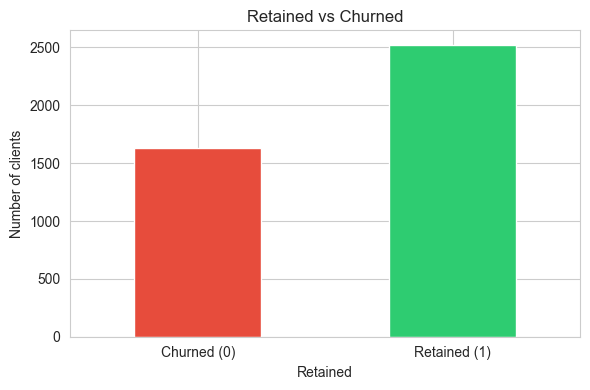

In [8]:
# count Retained target by index (first 0, then 1)
balance     = df_train['Retained'].value_counts().sort_index()
balance_pct = df_train['Retained'].value_counts(normalize=True).sort_index().round(3)

print("Counts:\n", balance, sep='')
print("\nProportions:\n", balance_pct, sep='')

# plot
fig, ax = plt.subplots(figsize=(6, 4))
balance.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Retained vs Churned')
ax.set_xticklabels(['Churned (0)', 'Retained (1)'], rotation=0)
ax.set_ylabel('Number of clients')
plt.tight_layout()
plt.show()

The target is moderately imbalanced, 60.7% retained vs 39.3% churned. This
is not extreme enough to require resampling, but it does rule out accuracy as a
meaningful evaluation metric: a model that always predicts "retained" would
already score 60.7%. We'll use ROC-AUC and F1 and treat the majority-class
baseline (60.7%) as the minimum bar any useful model has to beat.

### 5.2 Missing values

Different columns have very different rates of missingness. A few patterns to
notice upfront:

- `Early_RPL` has many nulls: it's the first communication invitation date, and
  is likely only recorded when the school reached a certain funnel stage.
- The CRM meeting dates (`FirstMeeting`, `LastMeeting`) are missing whenever the
  school held no meetings at all.
- `Special_Pay` is missing for most rows. We'll let imputation handle it, but
  such a high missingness rate is itself a signal worth keeping in mind.

                                Count  Percent
Special_Pay                      3329     80.2
Early_RPL                        1168     28.1
rpl_window_days                  1168     28.1
DifferenceTraveltoFirstMeeting    661     15.9
LastMeeting                       661     15.9
FirstMeeting                      661     15.9
DifferenceTraveltoLastMeeting     661     15.9
To_Grade                          269      6.5
From_Grade                        226      5.4
SchoolSizeIndicator               169      4.1
FPP_to_School_enrollment          159      3.8
MDR_High_Grade                    126      3.0
SchoolGradeTypeLow                112      2.7
SchoolGradeType                   112      2.7
Total_School_Enrollment           112      2.7
Income_Level                      112      2.7
CRM_Segment                       112      2.7
SPR_New_Existing                  112      2.7
MDR_Low_Grade                     112      2.7
School_Type                       112      2.7


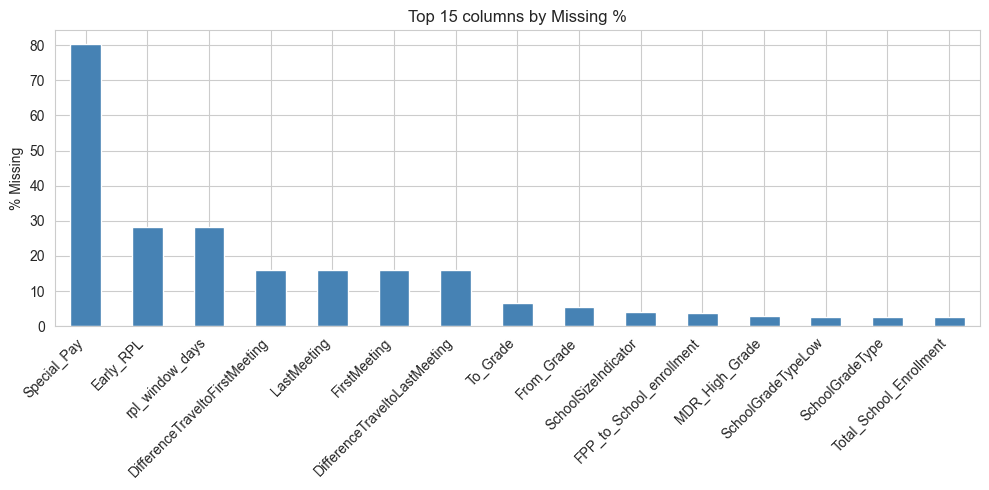

In [9]:
# count missing values per column (keep only missing > 0)
missing     = df_train.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(1)
print(pd.DataFrame({'Count': missing, 'Percent': missing_pct}).head(20))

# plot the top 15
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 columns by Missing %')
ax.set_ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

A few observations:

- `Special_Pay` has about 80% missing values. Only four rows have the value '0',
  and 3,329 out of 4,153 training rows have no value at all.
- The four meeting-related columns (`DifferenceTraveltoFirstMeeting`,
  `LastMeeting`, `FirstMeeting`, `DifferenceTraveltoLastMeeting`) all have
  identical missingness (661). This means they are populated or missing as a
  block, probably because they come from the same CRM event: if a booking has
  no `FirstMeeting` recorded, it won't have any of the other meeting fields.
- Eight columns have exactly 112 missing values (2.7%): `SchoolGradeTypeLow`,
  `SchoolGradeType`, `Total_School_Enrollment`, `Income_Level`, `CRM_Segment`,
  `SPR_New_Existing`, `MDR_Low_Grade`, `School_Type`. This matches the coverage
  report from section 4: CRM coverage was 97.3%, so the missing 2.7% of 4,153
  is roughly 112. All eight columns come from the CRM table, which confirms
  they go missing together whenever the CRM join fails.

One open question is whether keeping or dropping the `Special_Pay` missingness
noticeably changes the baseline model. We'll let imputation handle it first and
revisit only if needed.

As a sanity check, we run the same missingness test on the test set:

In [ ]:
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
missing_test_pct = (missing_test / len(df_test) * 100).round(1)
print(pd.DataFrame({'Count': missing_test, 'Percent': missing_test_pct}).head(20))

### 5.3 Retention rate by categorical variable

Here we look at how `Retained` moves across the levels of each categorical
feature. Essentially, we compute the average retention rate inside each bucket;
if the rate changes a lot across buckets, the feature carries signal.

One caveat first. We initially wanted to use the `DepartureMonth` column, which
only takes the values "January" and "December". A quick cross-check against the
actual `Departure_Date` showed an obvious discrepancy:

In [10]:
# Compare the two columns directly
pd.crosstab(df_train['DepartureMonth'], df_train['departure_month_num'])

# And check against actual departure dates
print(df_train[['DepartureMonth', 'departure_month_num', 'Departure_Date']].head(20))

# Also check if DepartureMonth might actually match another date column's month
print("DepartureMonth vs Initial_System_Date month:")
print(pd.crosstab(
    df_train['DepartureMonth'],
    df_train['Initial_System_Date'].dt.month
))

   DepartureMonth  departure_month_num Departure_Date
0         January                    4     2019-04-07
1         January                    4     2019-04-30
2         January                    3     2019-03-17
3         January                    5     2019-05-08
4         January                    3     2019-03-17
5         January                    6     2019-06-23
6         January                    3     2019-03-07
7         January                    3     2019-03-09
8         January                    5     2019-05-03
9         January                    4     2019-04-29
10        January                    3     2019-03-30
11        January                    3     2019-03-16
12        January                    3     2019-03-09
13        January                    6     2019-06-16
14        January                    4     2019-04-29
15        January                    5     2019-05-17
16        January                    4     2019-04-27
17        January           

So the `DepartureMonth` column doesn't actually reflect departure timing.
It's documented as "month of departure" but only contains "January" (4,137) and
"December" (16), while the actual `Departure_Date` values span March to June.
Our best guess is that it's some kind of program-cycle label rather than a true
departure month. Either way, we use the month extracted from `Departure_Date`
(`departure_month_num`) for any seasonality analysis.

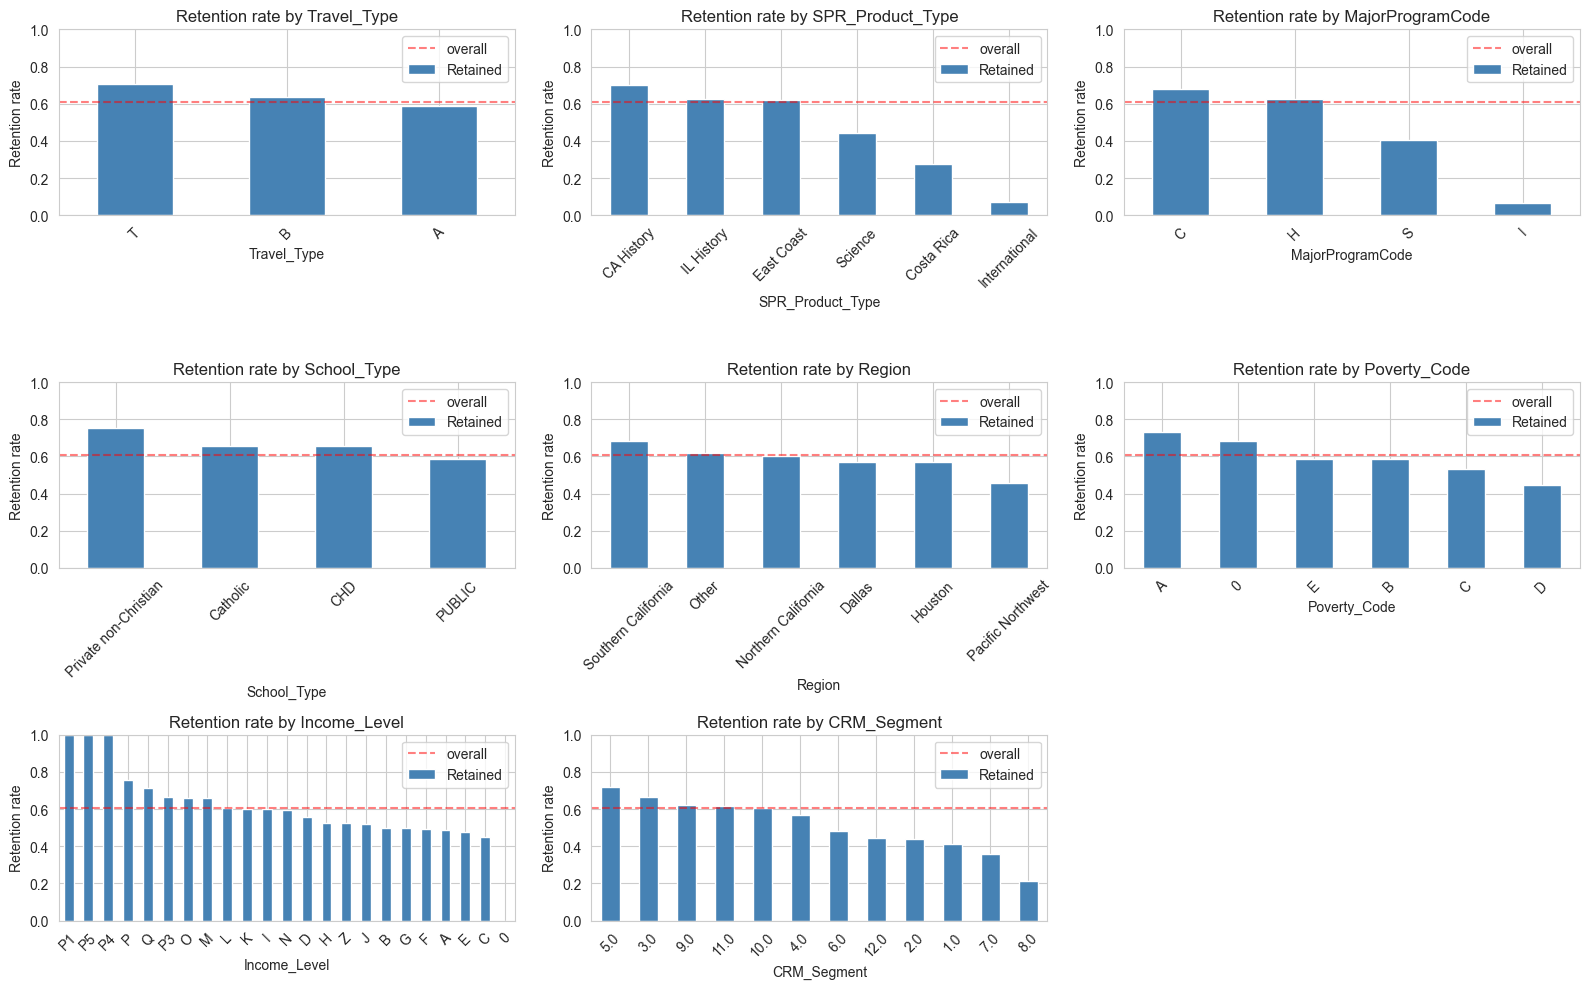

In [11]:
cat_features_to_check = ['Travel_Type', 'SPR_Product_Type', 'MajorProgramCode',
                         'School_Type', 'Region', 'Poverty_Code',
                         'Income_Level', 'CRM_Segment']

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
overall_rate = df_train['Retained'].mean()

for ax, col in zip(axes.flat, cat_features_to_check):
    # split by category, compute mean of Retained per bucket
    rates = df_train.groupby(col, observed=True)['Retained'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Retention rate by {col}')
    ax.set_ylabel('Retention rate')
    ax.set_ylim(0, 1)
    # red line at overall retention (60.7%)
    # bars above = better than average; below = worse than average
    ax.axhline(overall_rate, color='red', ls='--', alpha=0.5, label='overall')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

# hide the unused 9th subplot
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

Reading the plots: if all bars for a feature sit close to the red line,
the feature isn't telling us much (retention is the same regardless of category).
If the bars span roughly 0.3 to 0.85, the feature is highly predictive. It's
also worth checking the size of each category: a bucket with only a handful of
rows can look very good or very bad for purely random reasons.

We picked these categorical variables mostly for readability. Most of them have
between 2 and 5 levels, so the plots stay legible. Variables with many more
categories (like `Income_Level`) were left out of this view.

What stands out is that `SPR_Product_Type`, `MajorProgramCode` and `CRM_Segment`
show the widest spread across categories, so they're likely strong predictors.
`Travel_Type` and `Region` are flatter and probably carry weaker signal.

### 5.4 Numeric features vs target

For a handful of numeric variables we look at their distribution split by the
target. If the two distributions look clearly different, the feature is helping
the model separate classes.

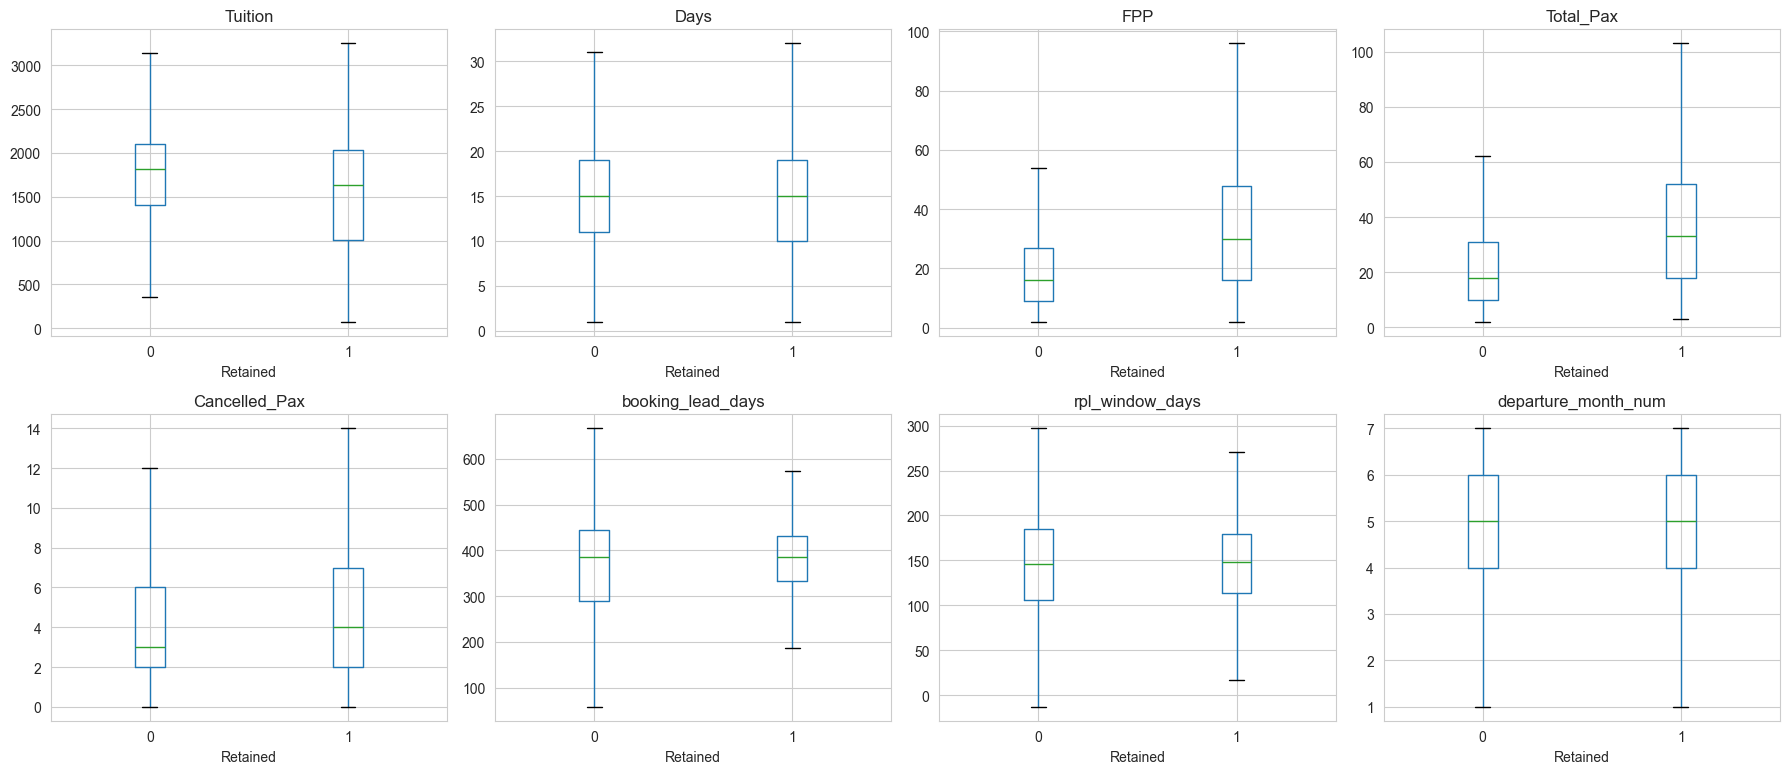

In [12]:
num_to_check = ['Tuition', 'Days', 'FPP', 'Total_Pax', 'Cancelled_Pax',
                'booking_lead_days', 'rpl_window_days', 'departure_month_num']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_to_check):
    df_train.boxplot(column=col, by='Retained', ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('Retained')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 5.5 Correlation matrix

Following the approach seen in class on the customer-satisfaction dataset, we
compute the correlation matrix for all numeric features. This serves two
purposes: identifying the features most correlated with `Retained`, and
spotting multicollinearity between predictors.

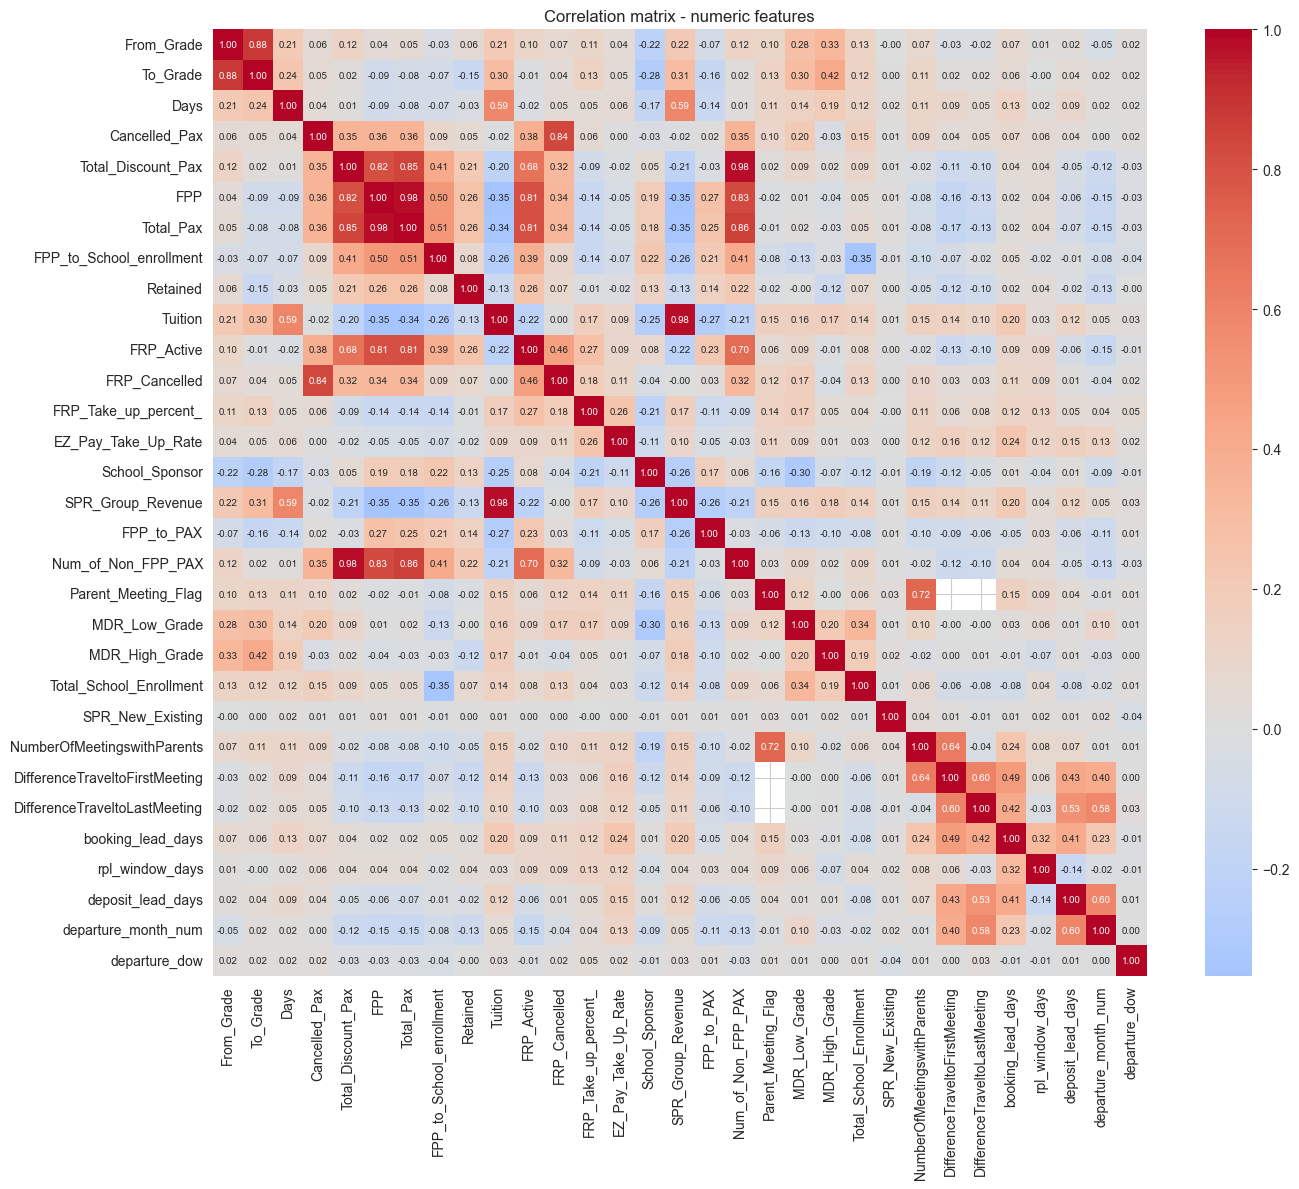

Correlation with Retained:
FPP                               0.264
Total_Pax                         0.264
FRP_Active                        0.255
Num_of_Non_FPP_PAX                0.216
Total_Discount_Pax                0.212
To_Grade                         -0.147
FPP_to_PAX                        0.145
School_Sponsor                    0.128
departure_month_num              -0.127
SPR_Group_Revenue                -0.126
Tuition                          -0.126
DifferenceTraveltoFirstMeeting   -0.123
MDR_High_Grade                   -0.122
DifferenceTraveltoLastMeeting    -0.097
FPP_to_School_enrollment          0.082
FRP_Cancelled                     0.073
Total_School_Enrollment           0.069
From_Grade                        0.061
NumberOfMeetingswithParents      -0.053
Cancelled_Pax                     0.051
rpl_window_days                   0.036
Days                             -0.035
Parent_Meeting_Flag              -0.024
deposit_lead_days                -0.021
EZ_Pay_Take_U

In [13]:
# correlation matrix for numeric features
num_cols = df_train.select_dtypes(include='number').columns
corr = df_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title('Correlation matrix - numeric features')
plt.tight_layout()
plt.show()

# correlation with the target, ranked
print("Correlation with Retained:")
print(corr['Retained'].drop('Retained').sort_values(key=abs, ascending=False).round(3))

The features most correlated with `Retained` are the ones to watch most
closely when we move to modelling. On top of that, a few pairs of features are
clearly highly correlated with each other (notably `FPP` and `Total_Pax`, or the
various grade columns). Keeping both in a logistic regression would introduce
multicollinearity, so we'll drop the redundant ones in the feature-selection
step.

### 5.6 F-test ranking of numeric features

As shown in class on the breast-cancer dataset, the F-test (`f_classif`) ranks
numeric features by how well they separate the two classes. This gives us a
quantitative counterpart to the visual boxplots above.

F-test scores (higher = more discriminating):
FPP                               311.60
Total_Pax                         311.59
FRP_Active                        289.65
Num_of_Non_FPP_PAX                203.72
Total_Discount_Pax                194.96
FPP_to_PAX                         88.38
To_Grade                           85.28
School_Sponsor                     68.82
departure_month_num                67.65
SPR_Group_Revenue                  67.24
Tuition                            66.45
MDR_High_Grade                     59.73
DifferenceTraveltoFirstMeeting     53.76
DifferenceTraveltoLastMeeting      32.78
FPP_to_School_enrollment           27.18
FRP_Cancelled                      22.23
Total_School_Enrollment            19.62
From_Grade                         14.94
NumberOfMeetingswithParents        11.00
Cancelled_Pax                      10.88
Days                                5.09
Parent_Meeting_Flag                 2.73
rpl_window_days                     2.35
deposit_lea

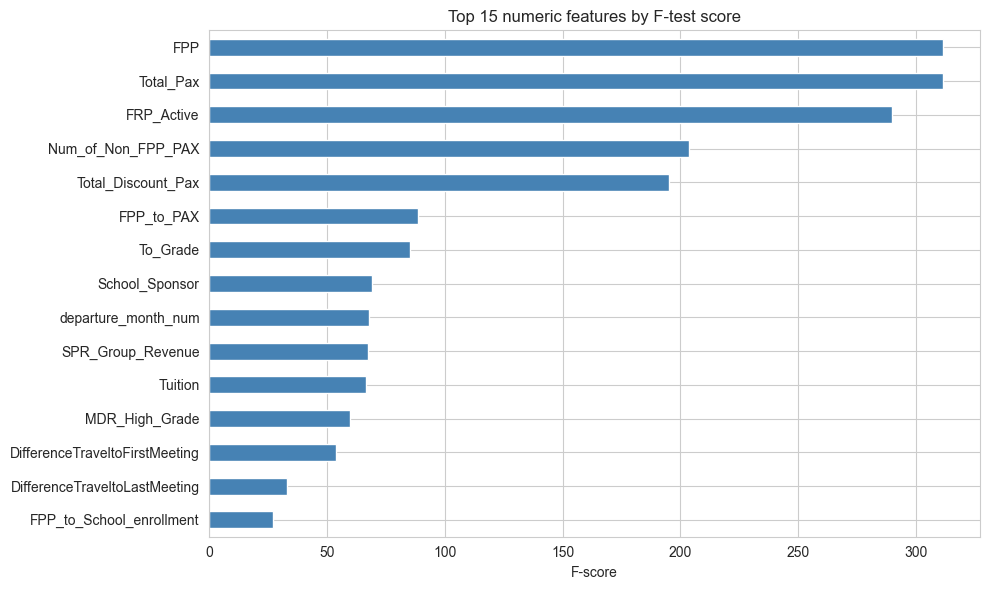

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

# Quick-and-dirty median fill just for the F-test ranking, since sklearn
# requires complete data. The real pipeline imputes fold-by-fold later on.
X_num = df_train.select_dtypes(include='number').drop(columns='Retained').fillna(df_train.median(numeric_only=True))
y = df_train['Retained']

selector = SelectKBest(f_classif, k='all')
selector.fit(X_num, y)

f_scores = pd.Series(selector.scores_, index=X_num.columns).sort_values(ascending=False)
print("F-test scores (higher = more discriminating):")
print(f_scores.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
f_scores.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 numeric features by F-test score')
ax.set_xlabel('F-score')
plt.tight_layout()
plt.show()

The top features by F-score are the ones that best separate retained from
churned clients. The ranking is consistent with the boxplots in 5.4 and the
correlations in 5.5, which is reassuring. Features with very low F-scores are
candidates for removal, although we'll let the model make the final call via
tree-based importance and logistic-regression coefficients.

## 6. Final feature selection

Building on the EDA, we drop four types of columns before feeding the model:

- Identifiers (`ID_SALES`, `ID_FINANCE`, `ID_CRM`), which are not predictive.
- Raw dates, which are already replaced by the engineered deltas in
  `preprocess()` (`booking_lead_days`, `rpl_window_days`, `deposit_lead_days`,
  `departure_month_num`). Keeping the raw dates alongside them would be
  redundant.
- Redundant grade parts: `GroupGradeType` and `SchoolGradeType` already encode
  the Low + High combination, so we keep only the combined version.
- Features with near-zero signal. From section 5.6, `departure_dow`,
  `SPR_New_Existing`, `MDR_Low_Grade` and `FRP_Take_up_percent_` all have
  F-scores below 0.25 and correlations close to zero. They're noise and we
  drop them.

We deliberately keep the highly correlated numeric pairs (`FPP`/`Total_Pax`,
the passenger-count cluster). Regularisation in logistic regression and
feature-importance in tree models both deal with collinearity well enough that
this isn't worth fighting.

The test-set `ID_SALES` is kept separately so we can attach it back to the
predictions at submission time.

In [15]:
def select_features(df):
    drop_cols = [
        # identifiers, not predictive
        'ID_SALES', 'ID_FINANCE', 'ID_CRM',
        # raw dates, replaced by engineered deltas in preprocess()
        'Departure_Date', 'Return_Date',
        'Early_RPL', 'Latest_RPL',
        'Initial_System_Date', 'Deposit_Date',
        'FirstMeeting', 'LastMeeting',
        # redundant grade parts, kept as combined Group/SchoolGradeType
        'GroupGradeTypeLow', 'GroupGradeTypeHigh',
        'SchoolGradeTypeLow', 'SchoolGradeTypeHigh',
        # near-zero F-score and correlation with target (see section 5.6)
        'departure_dow', 'SPR_New_Existing',
        'MDR_Low_Grade', 'FRP_Take_up_percent_',
    ]
    return df.drop(columns=[c for c in drop_cols if c in df.columns])


# keep test IDs for the submission file
test_ids = df_test['ID_SALES'].copy()

# split features from target
y_train = df_train['Retained']
X_train = select_features(df_train.drop(columns='Retained'))
X_test  = select_features(df_test)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
X_train.head(3)

X_train: (4153, 41)
X_test:  (630, 41)


,Program_Code,From_Grade,To_Grade,Group_State,Days,Travel_Type,Cancelled_Pax,Total_Discount_Pax,SPR_Product_Type,FPP,...,Income_Level,NumberOfMeetingswithParents,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SchoolGradeType,SchoolSizeIndicator,booking_lead_days,rpl_window_days,deposit_lead_days,departure_month_num
0,CC,10.0,10.0,CA,24,A,2,1,East Coast,26,...,O,2.0,332.0,215.0,Middle->Middle,S,371.0,-31.0,320.0,4
1,CC,5.0,6.0,CA,18,A,2,3,East Coast,21,...,O,1.0,238.0,244.0,Middle->Middle,S,410.0,1.0,190.0,4
2,CC,7.0,7.0,OR,13,A,0,1,East Coast,7,...,NaN,NaN,NaN,NaN,NaN,NaN,226.0,NaN,NaN,3


## 7. Preprocessing pipeline

We now build the `ColumnTransformer` that sklearn will apply inside each CV
fold. This is what guarantees no data leakage: imputation medians, scaler means
and one-hot categories are all learned on the training folds only, never on the
validation fold.

- Numeric columns (`Int8`, `float`, plain `int`): median imputation (robust to
  outliers) followed by standard scaling. Scaling is needed for logistic
  regression and harmless for trees.
- Categorical columns (`object` and `category`): most-frequent imputation plus
  one-hot encoding with `handle_unknown='ignore'`, so that any unseen category
  at prediction time doesn't crash the pipeline.

A small but important detail: we use `select_dtypes(include='number')` and
`include=['object', 'category']` because our preprocessing produces `Int8`
nullable integers and `category` dtype columns. A naive
`include=['int64', 'float64']` would silently drop many features.

In [16]:
# split train dataset into numeric and categorical columns
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# showcase columns
print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# Fill NaN with the column's median, then standardize.
# Median is less sensitive to outliers than the mean, which matters here
# because some columns (Tuition, SPR_Group_Revenue) have long tails.
# Scaling is needed for logistic regression.
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# fill NaN with the most common value, then one-hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer applies each pipeline to its column group and then
# concatenates the results into a single numeric matrix that any sklearn
# classifier can consume.
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])

Numeric columns: 26
Categorical columns: 15


## 8. Model comparison via cross-validation

We compare three models on top of a trivial majority-class baseline:

1. Logistic regression as a simple linear baseline.
2. Random forest, which captures non-linearities and interactions.
3. Gradient boosting, usually the strongest classical model on tabular data.

Evaluation uses 5-fold stratified cross-validation (stratification preserves
the class balance in each fold) and two metrics:

- ROC-AUC, which captures ranking quality across all decision thresholds.
- F1, which balances precision and recall on the positive class.

In [17]:
from sklearn.dummy import DummyClassifier

# Baseline + three candidate models
models = {
    'Baseline (majority)':  DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['roc_auc', 'f1'], n_jobs=-1,
    )
    results[name] = {
        'ROC-AUC':     scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
        'F1':          scores['test_f1'].mean(),
        'F1 std':      scores['test_f1'].std(),
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

best_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC: {best_name}")

                     ROC-AUC  ROC-AUC std      F1  F1 std
Baseline (majority)   0.5000       0.0000  0.7557  0.0003
Logistic Regression   0.8066       0.0145  0.7981  0.0099
Random Forest         0.9239       0.0122  0.8874  0.0097
Gradient Boosting     0.8492       0.0124  0.8274  0.0088

Best model by ROC-AUC: Random Forest


### 8.1 Sanity check: confusion matrix and classification report

ROC-AUC and F1 are nice aggregate scores, but they don't show what kinds of
mistakes the model actually makes. A confusion matrix (computed out-of-fold via
cross-validation) shows how often retained clients get misclassified as churned
and vice versa. This is what matters for the business.

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# refit the best pipeline and get out-of-fold predictions
best_pipe = Pipeline([('prep', preprocessor), ('clf', models[best_name])])
oof_preds = cross_val_predict(best_pipe, X_train, y_train, cv=cv, n_jobs=-1)

# print the confusion matrix
cm = confusion_matrix(y_train, oof_preds)
print("Confusion matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm,
                   index=['Churned (0)', 'Retained (1)'],
                   columns=['Pred Churned', 'Pred Retained']))

Confusion matrix (rows = true, columns = predicted):
              Pred Churned  Pred Retained
Churned (0)           1192            439
Retained (1)           160           2362


Reading the matrix:

- Top-left (1192): customers who actually churned and that the model correctly
  identified as churned.
- Top-right (439): customers who actually churned but that the model wrongly
  flagged as retained.
- Bottom-left (160): customers who actually retained but that the model
  wrongly flagged as churned.
- Bottom-right (2362): customers who actually retained and that the model
  correctly identified as retained.

Out of 4,153 customers, the model gets 3,554 (1192 + 2362) right, which is
roughly 86% overall accuracy.

In [19]:
# classification report with precision/recall/F1 per class
print("\nClassification report:")
print(classification_report(y_train, oof_preds, target_names=['Churned', 'Retained']))


Classification report:
              precision    recall  f1-score   support

     Churned       0.88      0.73      0.80      1631
    Retained       0.84      0.94      0.89      2522

    accuracy                           0.86      4153
   macro avg       0.86      0.83      0.84      4153
weighted avg       0.86      0.86      0.85      4153



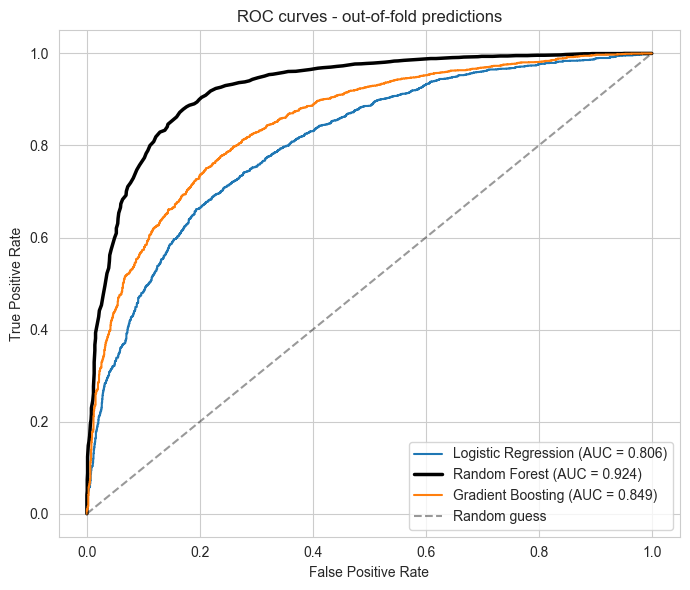

In [20]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    if name.startswith('Baseline'):
        continue  # dummy has no meaningful probability curve
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    oof_proba = cross_val_predict(
        pipe, X_train, y_train, cv=cv,
        method='predict_proba', n_jobs=-1,
    )[:, 1]
    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    # highlight the winner with a thicker, darker line
    lw = 2.5 if name == best_name else 1.5
    color = 'black' if name == best_name else None
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})',
            linewidth=lw, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves - out-of-fold predictions')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

A few things to note:

- Overall accuracy is 86%, which we consider a solid result for this dataset.
- The model is very good at spotting retained customers: 2362 / 2522 = 94%
  recall on the retained class.
- It's decent but not great at catching churners (73% recall). In business
  terms, for every 100 customers about to leave, the model flags 73 of them
  and 27 slip through unnoticed. This is worth highlighting in the
  presentation, because the cost of missing a churner is arguably higher than
  the cost of a false alarm on a retained one.

## 9. Final model, fit on all training data

Now that we've picked the winner, we refit it on the full training set (no
hold-out anymore, since we want every labelled row before predicting on test).

We also extract feature importances from the tree-based model. This is what the
business team actually cares about: it tells us which features drive the
prediction, and therefore where to focus retention efforts.

Top 15 features:
Total_Pax                         0.0462
FPP                               0.0456
FRP_Active                        0.0428
booking_lead_days                 0.0421
Total_School_Enrollment           0.0402
FPP_to_School_enrollment          0.0383
SPR_Group_Revenue                 0.0324
Tuition                           0.0322
FPP_to_PAX                        0.0317
DifferenceTraveltoFirstMeeting    0.0313
deposit_lead_days                 0.0296
rpl_window_days                   0.0292
DifferenceTraveltoLastMeeting     0.0278
EZ_Pay_Take_Up_Rate               0.0276
Cancelled_Pax                     0.0233
dtype: float64


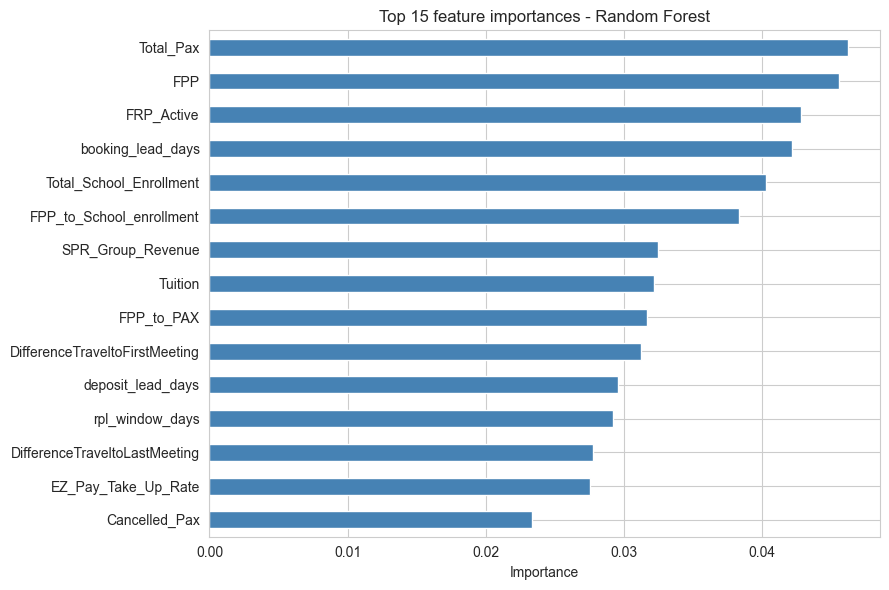

In [21]:
best_pipe = Pipeline([('prep', preprocessor), ('clf', models[best_name])])
best_pipe.fit(X_train, y_train)

# Rebuild feature names after one-hot encoding so the importances are labelled.
ohe_cats = (
    best_pipe.named_steps['prep']
             .named_transformers_['cat']
             .named_steps['encoder']
             .get_feature_names_out(cat_cols).tolist()
)
feature_names = num_cols + ohe_cats

final_clf = best_pipe.named_steps['clf']

if hasattr(final_clf, 'feature_importances_'):
    # tree-based model: use native feature importance
    importances = pd.Series(
        final_clf.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    print("Top 15 features:")
    print(importances.head(15).round(4))

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 15 feature importances - {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(final_clf, 'coef_'):
    # logistic regression: use absolute value of coefficients as a proxy
    coefs = pd.Series(
        np.abs(final_clf.coef_[0]),
        index=feature_names
    ).sort_values(ascending=False)

    print("Top 15 features by |coefficient|:")
    print(coefs.head(15).round(4))

    fig, ax = plt.subplots(figsize=(9, 6))
    coefs.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 15 features by |coef| - {best_name}')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print(f"Model {best_name} does not expose feature importances or coefficients.")

Three themes dominate the top features: group size (`FPP`, `Total_Pax`,
`FRP_Active`), financial commitment (`Tuition`, `SPR_Group_Revenue`,
`FPP_to_PAX`), and the timing of the booking (`departure_month_num`,
`booking_lead_days`). Larger groups, bigger financial stakes and trips that
were booked earlier in the cycle are all associated with retention.

## 10. Generating predictions for the test set

Final step: apply the trained pipeline to the test set and save the predictions
in the format required by the assignment (`ID_SALES, Retained`). We also print
a quick sanity check comparing the predicted retention rate to the one we saw
in training.

In [22]:
test_preds = best_pipe.predict(X_test)

# Submission file with exactly the two columns the assignment asks for
submission = pd.DataFrame({
    'ID_SALES': test_ids,
    'Retained': test_preds,
})

submission.to_csv('predictions.csv', index=False)

print(f"Saved {len(submission)} predictions to predictions.csv.")
print("\nPrediction distribution:")
print(submission['Retained'].value_counts())
print(f"Predicted retained rate: {test_preds.mean():.1%} "
      f"(training rate: {y_train.mean():.1%})")

Saved 630 predictions to predictions.csv.

Prediction distribution:
Retained
1    409
0    221
Name: count, dtype: int64
Predicted retained rate: 64.9% (training rate: 60.7%)


## 11. Business takeaways

Based on the feature importances from section 9, a clear churn profile emerges.
We group the top drivers into four families and translate them into concrete
actions Yeti Travel can take.

**Group size and trip scale.** `FPP`, `Total_Pax`, `FRP_Active` and
`Num_of_Non_FPP_PAX` dominate the importance ranking. Larger groups are more
likely to come back. Small groups are the first ones at risk and should be
monitored more closely.

**Financial commitment.** `Tuition`, `SPR_Group_Revenue` and `FPP_to_PAX` all
show up near the top. The more the school has invested per student, the more
likely it is to return. Low take-up on direct debit (`EZ_Pay_Take_Up_Rate`)
is a supporting signal for weaker financial engagement.

**Timing and engagement depth.** `departure_month_num`, `booking_lead_days`
and `rpl_window_days` suggest that how early the school starts engaging and
how long the engagement window stays open both matter. Schools with short
RPL windows and late bookings are worth flagging as higher risk.

**Relationship with the agency.** `NumberOfMeetingswithParents` and
`Parent_Meeting_Flag` are less dominant than the first three groups, but the
direction is intuitive: schools with more parent meetings are more likely to
return. The absence of any direct satisfaction data is the main blind spot in
the current dataset.

### Recommended actions for Yeti Travel

1. **Early-warning dashboard.** Plug the model's predicted probability back
   into a weekly report. Accounts above a churn-probability threshold are
   routed to a dedicated retention agent.
2. **Target the small-group segment.** Groups with low `FPP` / `Total_Pax`
   are the most at-risk bucket. A bundled offer that encourages one or two
   extra students per trip could shift them into the retained profile.
3. **Push early booking.** Time-limited incentives that reward clients who
   book early in the cycle would nudge `booking_lead_days` upwards, which the
   model associates with retention.
4. **Add a post-trip satisfaction signal.** The dataset has no direct measure
   of customer satisfaction. A simple post-trip survey would add a very
   informative feature to the next iteration of the model.